Este archivo detalla los analises utilizados en el capitulo 4

In [3]:
#### Importando modulos 
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [5]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio

    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad_diaria = df_rentabilidad.iloc[2:]

    return df_rentabilidad_diaria



In [6]:
#### Formula para limpiar datos
def cargar(df_original: pd.DataFrame, tipo: str):
    ### Copiando datos para no malograr
    df = df_original.copy()

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_posiciones= posiciones(df, empresas, tipo)    

    #### Calculado rentabilidades diarias de todas acciones
    df_rentabilidad_diaria = calc_rentabilidad(df_posiciones, empresas)
    
    return df_rentabilidad_diaria

In [7]:
#### Funcion para extraer estadisticas
def estadisticas(df:pd.DataFrame):
    ### Creando arreglo de estadisticas
    arr = []
    arr.append(df.mean())    # Promedio
    arr.append(df.median())  # Mediana
    arr.append(df.std(ddof=0))   # Des Est
    arr.append(df.min())     # Minimo
    arr.append(df.max())     # Maximo

    ### Buscando el exponente comun
    arr = np.array(arr, dtype=float)
    exponentes = np.floor(np.log10(np.abs(arr)))
    exp_comun = int(scipy.stats.mode(exponentes)[0])

    ### Ajustando valores
    resultados = arr/(10**exp_comun)
    resultados = np.round(resultados, 2)
    resultados = [int(df.shape[0])] + resultados.tolist()

    return (resultados, exp_comun)

In [8]:
#### Funcion para extraer data de rendimiento esperado, vol, y ratio sharpe
def extraccion(df: pd.DataFrame):
    df_rendis_esperado = df.mean(axis=0)
    df_vol = df.std(axis=0, ddof=0)
    df_ratio_sharpe = df_rendis_esperado/(df_vol + 1e-8)

    return df_rendis_esperado, df_vol, df_ratio_sharpe

In [9]:
#### Fucnion de visualizacion: tabla y bargraph
def visuales(pre_datos: list, post_datos: list, nom:str, exp: int):
    ### Uniendo los datos
    data = [pre_datos, post_datos]

    ### Tabla
    ## Nombre de columnas y filas
    cols = ['N', 'Media', 'Mediana', 'Des.Est', 'Mínimo', 'Máximo']
    rows = ['Pre-LSTM', 'Post-LSTM']

    ## Cofigurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        colLabels=cols,
        colColours=["#13a82c"]*len(cols),
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"Estadística - {nom} (Valores: e{exp})", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()


    ### Bar graph
    ## Hiperparams
    ANCHURA = 10
    ALTURA = 5
    WIDTH = 0.25
    ## Configurando datos
    data = np.array([pre_datos[1:], post_datos[1:]])
    cols = ['Pre-LSTM', 'Post-LSTM']
    x_idxs = ['Media', 'Mediana', 'Des.Est', 'Mínimo', 'Máximo']
    x = np.arange(len(x_idxs))   # Se hace para el pretest y posttest
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    for i, col in enumerate(cols):
        ax.bar(x + i * WIDTH, data[i], WIDTH, label = col)

    ## Configurando grafo
    ax.set_xlabel(f'Estadística', fontsize=ANCHURA)
    ax.set_ylabel(f'Valores (* e{exp})', fontsize=ANCHURA)
    ax.set_title(f'Estadística - {nom}', fontsize=ANCHURA)
    ax.set_xticks(x + WIDTH)
    ax.set_xticklabels(x_idxs)
    ax.grid(True, axis='y')
    ax.tick_params(axis='x', labelsize=0.8*ANCHURA) 
    ax.tick_params(axis='y', labelsize=0.85*ANCHURA) 
    ax.legend(fontsize=ANCHURA)



In [ ]:
#### Funcion para medir la normalidad
def normalidad(ds_pre: pd.Series, ds_post: pd.Series, nom: str):
    ### Transformando dataframes a arreglos
    arr_pre = ds_pre.to_list()
    arr_post = ds_post.to_list()
    arr_diff = ds_post.values - ds_pre.values
    arr_diff = arr_diff.tolist()

    ### Haciendo pruebas
    pre_estad, pre_pvalor = stats.kstest(arr_pre, 'norm')
    post_estad, post_pvalor = stats.kstest(arr_post, 'norm')
    diff_estad, diff_pvalor = stats.kstest(arr_diff, 'norm')

    ### Arreglando formato de numeros
    pre_pvalor = format(pre_pvalor, '.3e')
    post_pvalor = format(post_pvalor, '.3e')
    diff_pvalor = format(diff_pvalor, '.3e')
    pre_estad = pre_estad.round(5)
    post_estad = post_estad.round(5)
    diff_estad = diff_estad.round(5)

    ### Visualizacion Tabla
    ## Preparacion
    data = [[32, pre_estad, pre_pvalor],[32, post_estad, post_pvalor], [32, diff_estad, diff_pvalor]]
    cols = ['N', 'Estadístico', 'P-valor']
    rows = ['Pre-Rendimiento', 'Pos-Rendimiento', 'Diferencia']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        cellColours=[['white','white','yellow']] * 3, 
        colLabels=cols,
        colColours=["#e9820d"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"KS Prueba de Normalidad - {nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()

In [86]:
#### Formula para prueba de Wilcoxon
def wilcoxon(ds_pre: pd.Series, ds_post: pd.Series, nom: str):
    ### Transformando dataframes a arreglos
    arr_diff = ds_post.values - ds_pre.values
    arr_diff = arr_diff.tolist()
    print(arr_diff)

    ### Realizando prueba
    if nom.lower() == 'rendimiento': estad, pvalor = stats.wilcoxon(arr_diff, alternative='greater')
    elif nom.lower() == 'volatilidad': estad, pvalor = stats.wilcoxon(arr_diff, alternative='less')

    ### Arreglando formato de numeros
    estad = estad.round(5)
    # pvalor = pvalor.round(10)
    pvalor = format(pvalor, '.3e')

    ### Visualizacion tabla
    data = [[32, estad, pvalor]]
    cols = ['N', 'Estadístico', 'P-valor']
    rows = [f'Pre-{nom} - \nPost-{nom}']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        cellColours=[['white','white','yellow']],
        colLabels=cols,
        colColours=["#e9820d"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"Prueba Wilcoxon - {nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()


[-0.0014322993858824477, 0.013339141588094473, -0.0011373578185017224, -0.001432388221332635, -0.001570642898850195, -0.0014882767914468679, -0.0016934181039732388, -0.0014845305174965764, -0.0015880691214626534, -0.0013883263965523418, -0.001569896951193089, -0.0014127130823830612, -0.0015210390662424868, -0.0013914114464721548, -0.0024267356363179456, -0.0015000036436753224, -0.0014679908464757855, -0.0014546741599254683, -0.0016187311709453954, -0.0014997710340963165, -0.0015780029125026188, -0.0016767933805422138, -0.0014674728419781175, -0.0015785421039827413, -0.0013228348703640904, -0.0017060605708295934, -0.001410397374430958, -0.001361456473775221, -0.0014319774366793698, -0.0015579033204743092, -0.0013189412753899597, -0.0015243916210713432]


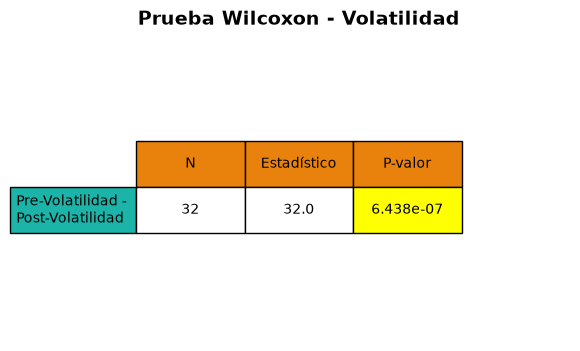

In [88]:
#### Evaluaciones
### Cargando datos
df_rendis = pd.read_csv('retornos.csv', index_col='Date')

### Analisis del pre-test
df_rand_rentabilidad = cargar(df_rendis, 'rand')
ds_rand_rendis_esperado, ds_rand_vol, ds_rand_ratio = extraccion(df_rand_rentabilidad)
rand_rendis_esperado_estad, rand_rendis_exp = estadisticas(ds_rand_rendis_esperado)
rand_vol_estad, rand_vol_exp = estadisticas(ds_rand_vol)
rand_ratio_estad, rand_ratio_exp = estadisticas(ds_rand_ratio)

### Analisis del post-test
df_lstm_rentabilidad = cargar(df_rendis, 'todo')
ds_lstm_rendis_esperado, ds_lstm_vol, ds_lstm_ratio = extraccion(df_lstm_rentabilidad)
lstm_rendis_esperado_estad, lstm_rend_exp = estadisticas(ds_lstm_rendis_esperado)
lstm_vol_estad, lstm_vol_exp = estadisticas(ds_lstm_vol)
lstm_ratio_estad, lstm_ratio_exp = estadisticas(ds_lstm_ratio)

# print(rand_rendis_exp, rand_vol_exp, rand_ratio_exp, lstm_rend_exp, lstm_vol_exp, lstm_ratio_exp)

### Visuales de estadisticas
# visuales(rand_rendis_esperado_estad, lstm_rendis_esperado_estad, "Rendimiento", rand_rendis_exp)
# visuales(rand_vol_estad, lstm_vol_estad, 'Volatilidad', rand_vol_exp)
# visuales(rand_ratio_estad, lstm_ratio_estad, 'Ratio Sharpe', rand_ratio_exp)

### Normalidad
# normalidad(ds_rand_rendis_esperado, ds_lstm_rendis_esperado, 'Rendimiento')
# normalidad(ds_rand_vol, ds_lstm_vol, 'Volatilidad')

### Wilcoxon
# wilcoxon(ds_rand_rendis_esperado, ds_lstm_rendis_esperado, 'Rendimiento')
wilcoxon(ds_rand_vol, ds_lstm_vol, 'Volatilidad')

